# Import Libraries

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
import tarfile
import shutil
import glob
import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits 
from spectral_cube import SpectralCube
from astropy import wcs
from astropy.coordinates import SkyCoord
from astroquery.alma import Alma
#from astropy.constants import c as speed_of_light
from astropy.coordinates import SkyCoord
from scipy.constants import c
from astropy.wcs import WCS
import re
from astropy.table import Table
from astropy.visualization.wcsaxes import add_beam

# Dowlaod the ALMA data using Astroquery

In [68]:
#Downloading files with astroquery is not working right now. We need another approach to downlod the desired fits file rom the ALMA Archive
#we will figure out later how to fix this part of the code""


#Create a ALMA project
alma = Alma()

# Set up Project code
project_code = "2019.1.00912.S"

#Query the project with ALMA archive
results = alma.query(payload=dict(project_code=project_code))
#print(results.colnames)
#print(results["frequency_support"])


In [69]:
#print(results["frequency_support"])
#print(results.colnames)

In [70]:
#results["member_ous_uid","target_name","bandwidth","band_list","obs_id",'frequency_support']

In [71]:
#print(results["bandwidth"])

In [64]:
#print(results[0])
uid_info_dict = {}
for result in results:
    #print(result)
    uid = result["member_ous_uid"]
    #print(uid)
    freq_range = str(result["frequency_support"])[1:15].split("..") 
    uid_info_dict[uid] = freq_range
    #print(uid_info_dict[uid])
#print(uid_info_dict)

In [65]:
#print(result)

In [22]:
# Get mous IDS

mous_ids = results["member_ous_uid"]

#print("\nMOUS IDs:")
#for m in mous_ids:
   #print(m)

In [17]:
# Get data info

data_info = alma.get_data_info(mous_ids, expand_tarfiles=True)

#print("\nData columns:")
#print(data_info.colnames)

In [249]:
#access the urls from ALMA data

#urls = data_info["access_url"]

In [251]:
#Now we only intersted in pbcor.fits files from all ALMA data

# Filter fits files only

#cube_file = [
    #url for url in urls
    #if (
        #"cube" in url.lower()
        #and ".i.pbcor" in url.lower()
        #and ".fits" in url.lower()
    #)
#]

#print(f"Found {len(cube_file)} cube.i.pbcor FITS files")

#for f in cube_file:
    #print(f)

In [73]:
#Create a ALMA project
#alma = Alma()

# Set up Project code
#project_code = "2019.1.00912.S"

# define a function to query the ALMA project

#"""Here we are only interested in SiO (8-7) molecular lines therefore we setup a frequency range
#with respect to the SiO rest frequency = 347.33GHz"""

#def alma_q(project_code,
              #rest_freq = 347.33 * u.GHz, #rest frequency of SiO (J = 8-7)
               #freq_range = 1* u.GHz): # This window decide a lower and upper limit of the frequncy with respect to the rest frequncy of SiO

    #Now connect with ALMA Archive
    #results = alma.query(payload=dict(project_code=project_code))
    
    #create an empty list
   # filter_freq = []

    #Define a range of frequnecy to search files between that range
   # min_freq = (rest_freq - freq_range).to(u.GHz).value
   # max_freq = (rest_freq + freq_range).to(u.GHz).value
    #print(f"frequency range: {min_freq:.2f} - {max_freq:.2f} GHz")
    
    #Create a for loop to all ALMA results and convert frequnecy into text since its sotred as a string in the ALMA data
   # for row in results:

       # freq_text = str(row["frequency_support"])
        #print(freq_text)

       #Create an empty list to store data after filtering
        #freq_parts = [] 

        # Replace commas to spaces and split string by spaces
        #for item in freq_text.replace(",", " ").split():

            #try:
                # keep only first part of the freuqncy range
                #item = item.split("..")[0]

               #remove all non- numeric characters and keep only floats/numbers
                #clean = "".join(x for x in item if x.isdigit() or x == ".")

                #if clean != "": #if clean is not empty
                   # freq_parts.append(float(clean)) # convert to float and store in the list
                    #print(clean)
                    
                    

           # except:
               # pass

        # check if the range covering SiO window
        #for f in freq_parts:
            #if min_freq <= f <= max_freq:
                #filter_freq.append(row)
                #print(row["member_ous_uid"],row["dataproduct_type"],row["calib_level"])
                #print(row['frequency'])
                #break
    #print("Total matches:", len(filter_freq))
    
    

    #return filter_freq
   


# This command to run function
#freq_data = alma_q(project_code)
#print(len(freq_data))
#print(freq_data[0]["access_url"])
#print(freq_parts)


In [72]:
#since filtering data showing repetetion of files therfore we will chose only unique files corrsponds to Sio (J = 8-7) molecular line
#unique = {} #create an empty dictionary and store datasetID with row

#for row in freq_data:
    #uid = row["member_ous_uid"] #unique dataset
    #unique[uid] = row #store in dictionary

#clean_list = list(unique.keys()) #convert back to list of rows
#print(freq_data)
#clean_list = unique
#print(len(clean_list))
#print(type(clean_list))
#print(clean_list)

In [143]:

#alma.cache_location = '/users/skaur/Machine-Learning-Project/Astromorph_project/ALMA_Query_files'


In [74]:
#import astroquery
#print("Astroquery version:", astroquery.__version__)


#for method in dir(alma):
    #if "data" in method.lower() or "download" in method.lower() or "retrieve" in method.lower():
        #print(method)

In [75]:
#alma.archive_url = 'https://almascience.eso.org' 

In [76]:
#for uid in clean_list:
     #alma.retrieve_data_from_uid(uid)
#for uid in clean_list:
    #table = unique[uid]
    #print(table['access_url'])
    #filelist = alma.download_files(table['access_url'])


In [77]:


# your UID list
#uid_list = clean_list   # must contain uid://...

#all_fits_urls = []

#for uid in uid_list:

    #print("\nProcessing UID:", uid)

    # STEP 1: get all files for this UID
    #info = alma.get_data_info(uid, expand_tarfiles=True)

    # STEP 2: extract ONLY FITS files
   # fits_urls = [
        #str(row)
        #for row in info["access_url"]
        #if "cube.pbcor.fits" in str(row)
    #]

    #print("FITS found:", len(fits_urls))
    #uidname = uid[6:].replace('/','_')
    #fits_urls = 'https://almascience.nrao.edu/dataPortal/member.uid___{}.Serpens_South_C7_sci.spw31.cube.I.pbcor.fits'.format(uidname)
    #all_fits_urls.append(fits_urls)

# STEP 3: download ALL selected FITS files
#print("\nTotal FITS files:", len(all_fits_urls),all_fits_urls)

#downloaded_files = alma.download_files(all_fits_urls)

#print("\nDownload complete")
#for f in downloaded_files:
    #print(f)

# Download ALMA data using UIDs from the ALMA Archive

In [78]:

alma = Alma()
source_name = "NGC1333-IRAS2A"
alma.cache_location = '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery'
#fits_url = "https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28b.Serpens_South_C7_sci.spw33.cube.I.pbcor.fits"
#fits_url = "https://almascience.nrao.edu/dataPortal/member.uid___A001_X15a1_X1a12.IC348_sci.spw39.cube.I.pbcor.fits"
fits_url = "https://almascience.nrao.edu/dataPortal/member.uid___A001_X15a1_X1a14.NGC1333-IRAS2A_sci.spw39.cube.I.pbcor.fits"
#fits_url = "https://almascience.nrao.edu/dataPortal/member.uid___A001_X133d_X3cb5.iras16293-2422_sci.spw18.cube.I.pbcor.fits"

#make a folder to save fits files
output_folder = "alma_astroquery"
os.makedirs(output_folder, exist_ok=True)

# Download the FITS file
downloaded_files = alma.download_files([fits_url])

print(downloaded_files)

# Rename and move to the desired folder
for file_path in downloaded_files:
    new_name = f"{source_name}.fits"   # clean name
    save_path = os.path.join(output_folder, new_name)

    shutil.move(file_path, save_path)

print("Saved as:", save_path)

['/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/member.uid___A001_X15a1_X1a14.NGC1333-IRAS2A_sci.spw39.cube.I.pbcor.fits']
Saved as: alma_astroquery/NGC1333-IRAS2A.fits


# Load ALMA fits file

In [58]:
#pip install spectral-cube

In [79]:
#Open fits file for SiO molecule

"""Edit fits file and generate moment 0 and moment 8 maps"""

cube = SpectralCube.read("/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/NGC1333-IRAS2A.fits")
#print(cube)
#print(cube.spectral_axis)
#filename = "/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/C7.fits" 
#data = hdul[0].data
header = cube.header
#wcs = WCS(header)
#wcs_2d = WCS(header).celestial

In [80]:
cube_vel = cube.with_spectral_unit(
    u.km/u.s,
    velocity_convention='radio',
    rest_value=347.33*u.GHz
)
print(cube_vel)

#I first tried to buil moment 0 map with entire cube but enable to see emission so I decided to use velocity ranges to see clear outflow/knot
#morphology
#subcube = cube_vel.spectral_slab(-20*u.km/u.s, 22*u.km/u.s)

SpectralCube with shape=(956, 450, 450) and unit=Jy / beam:
 n_x:    450  type_x: RA---SIN  unit_x: deg    range:    52.226734 deg:   52.236362 deg
 n_y:    450  type_y: DEC--SIN  unit_y: deg    range:    31.239493 deg:   31.247725 deg
 n_s:    956  type_s: VRAD      unit_s: km / s  range:     -195.309 km / s:     207.253 km / s


In [81]:
# Create moment 0 map
mom0 = cube.moment(order=0)


In [82]:
mom8 = cube.max(axis = 0, how='ray') #go pixel by pixel and extract the full spectrum at that pixel

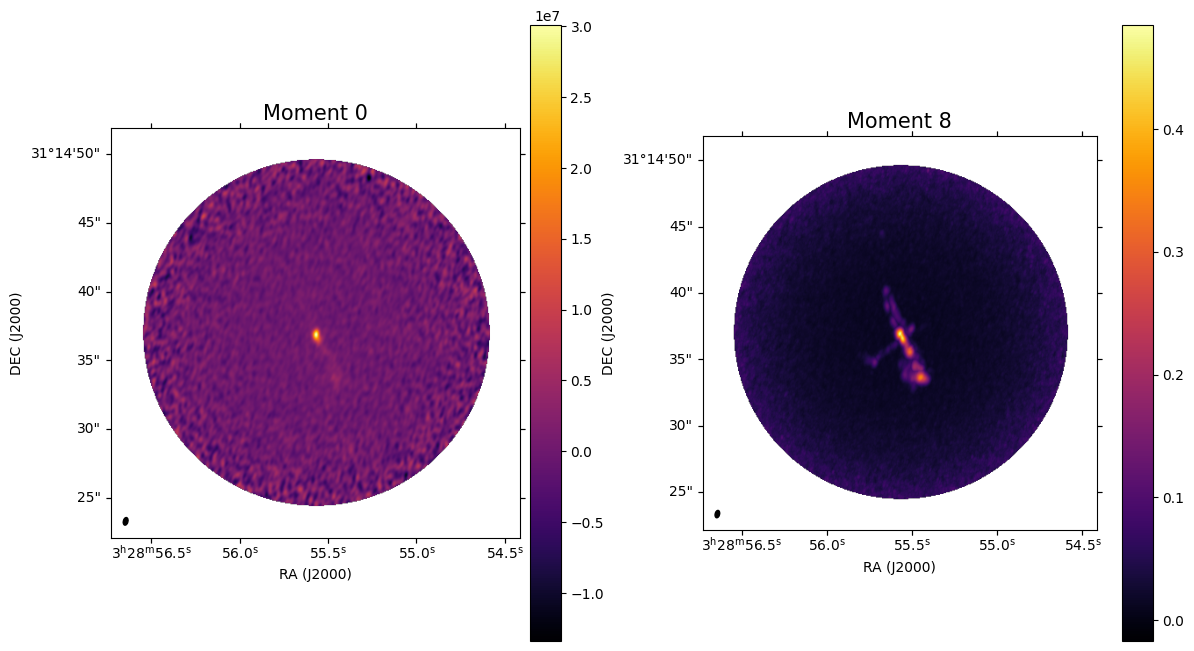

In [84]:

#Plot momment maps
wcs_2d = mom0.wcs.celestial
fig = plt.figure(figsize=(14, 8))
ax0 = fig.add_subplot(1, 2, 1, projection=wcs_2d)
ax1 = fig.add_subplot(1, 2, 2, projection=wcs_2d)

img0= ax0.imshow(mom0.value, origin='lower',cmap = 'inferno')
img1 = ax1.imshow(mom8.value, origin='lower',cmap = 'inferno')

ax0.set_title('Moment 0',size = 15)
ax1.set_title('Moment 8',size = 15)
ax0.set_xlabel('RA (J2000)')
ax0.set_ylabel('DEC (J2000)')
ax1.set_xlabel('RA (J2000)')
ax1.set_ylabel('DEC (J2000)')
add_beam(ax0,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')

add_beam(ax1,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')
cbar0 = fig.colorbar(img0, ax = ax0, pad = 0.02)
cbar1 = fig.colorbar(img1, ax = ax1 )
plt.savefig('NGC1333-IRAS2A_mom0_mom8_cube.png', dpi=300, bbox_inches='tight')
plt.show()

In [85]:
#Save moment 0 amd moment 8 maps as a fits file

# --- MOMENT 0 ---
hdu_mom0 = fits.PrimaryHDU(data=mom0.value, header=mom0.wcs.to_header())
hdu_mom0.writeto('NGC1333-IRAS2A_mom0_cube.fits', overwrite=True)

# --- MOMENT 8 ---
hdu_mom8 = fits.PrimaryHDU(data=mom8.value, header=mom8.wcs.to_header())
hdu_mom8.writeto('NGC1333-IRAS2A_mom8_cube.fits', overwrite=True)